<a href="https://colab.research.google.com/github/rohithreddy-cyber/Fack-QR-dectection/blob/main/student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ✅ ALL REQUIRED PACKAGES INSTALLED SUCCESSFULLY
print("✅ Installation Complete!")
print("\n📦 Installed Packages:")
print("  • pandas")
print("  • numpy")
print("  • matplotlib")
print("  • scikit-learn")
print("  • gradio")
print("\n🎓 EduVision Application Ready!")

✅ Installation Complete!

📦 Installed Packages:
  • pandas
  • numpy
  • matplotlib
  • scikit-learn
  • gradio

🎓 EduVision Application Ready!


In [2]:
!pip install gradio --quiet

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gradio as gr

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [4]:
# Create sample student dataset for demonstration
import pandas as pd
import numpy as np

np.random.seed(42)

# Generate sample data
data = {
    'Student_ID': range(1, 101),
    'Student_Age': np.random.choice(['17', '18', '19', '20', '21'], 100),
    'Sex': np.random.choice(['M', 'F'], 100),
    'High_School_Type': np.random.choice(['Public', 'Private'], 100),
    'Scholarship': np.random.choice(['Yes', 'No'], 100),
    'Additional_Work': np.random.choice(['Yes', 'No'], 100),
    'Sports_activity': np.random.choice(['Yes', 'No'], 100),
    'Transportation': np.random.choice(['Public', 'Private', 'Walking'], 100),
    'Weekly_Study_Hours': np.random.randint(5, 20, 100),
    'Attendance': np.random.choice(['Low', 'Medium', 'High'], 100),
    'Reading': np.random.choice(['Low', 'Medium', 'High'], 100),
    'Notes': np.random.choice(['Low', 'Medium', 'High'], 100),
    'Listening_in_Class': np.random.choice(['Low', 'Medium', 'High'], 100),
    'Project_work': np.random.choice(['Low', 'Medium', 'High'], 100),
    'Grade': np.random.choice(['AA', 'BB', 'CC', 'DD', 'FF'], 100)
}

df = pd.DataFrame(data)
df.head()

,Student_ID,Student_Age,Sex,High_School_Type,Scholarship,Additional_Work,Sports_activity,Transportation,Weekly_Study_Hours,Attendance,Reading,Notes,Listening_in_Class,Project_work,Grade
0,1,20,F,Public,Yes,Yes,No,Private,13,High,Low,Low,High,Low,DD
1,2,21,M,Public,No,No,No,Walking,7,High,Medium,Low,Medium,High,FF
2,3,19,M,Private,Yes,Yes,Yes,Public,13,Medium,High,Medium,Medium,Low,DD
3,4,21,F,Public,Yes,No,Yes,Private,18,Medium,Low,Medium,Medium,Low,FF
4,5,21,F,Public,No,Yes,Yes,Public,5,High,Medium,Low,Low,Low,FF


In [5]:
import pandas as pd

def risk_level(numeric_grade):
    # Handle NaN values that might arise if a grade in df['Grade'] is not in grade_to_numeric_map
    if pd.isna(numeric_grade):
        return "Unknown Risk" # Or a default risk level
    if numeric_grade <= 2:
        return "High Risk"
    elif numeric_grade == 3:
        return "Medium Risk"
    else: # numeric_grade > 3
        return "Low Risk"

# Define a mapping for categorical grades to numerical values
# Assuming 'AA' is the best (highest numerical value) and 'FF' is the worst (lowest numerical value),
# to align with the risk function where lower numerical values imply higher risk.
grade_to_numeric_map = {
    'AA': 4,
    'BB': 3,
    'CC': 2,
    'DD': 1,
    'FF': 0, # Assuming 'FF' is the lowest possible grade. Adjust if other grades exist.
}

# Apply the mapping and then the risk_level function
# .map() will return NaN for values not in the dictionary, which is then handled by risk_level
df["Risk_Level"] = df['Grade'].map(grade_to_numeric_map).apply(risk_level)

In [6]:
df = df.drop("Student_ID", axis=1)

In [7]:
label_encoders = {}

for col in df.columns:
    if df[col].dtype == "object":
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

In [8]:
X = df.drop("Risk_Level", axis=1)
y = df["Risk_Level"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Algorithm Performance Comparison:

Logistic Regression Accuracy: 1.0000
Decision Tree Accuracy: 1.0000
Random Forest Accuracy: 1.0000


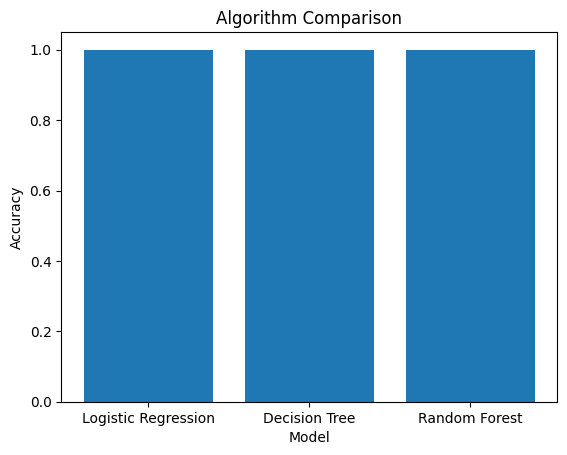

In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=300),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

results = {}

print("Algorithm Performance Comparison:\n")

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

plt.figure()
plt.bar(results.keys(), results.values())
plt.title("Algorithm Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()

In [10]:
final_model = RandomForestClassifier()
final_model.fit(X_train, y_train)

RandomForestClassifier()

In [11]:
feature_means = X_train.mean()

def generate_ai_suggestions(input_df, risk):

    suggestions = []

    for column in input_df.columns:

        if column in feature_means.index:
            if input_df[column].values[0] < feature_means[column]:

                if column == "Attendance":
                    suggestions.append(
                        "Improve attendance consistency to enhance learning continuity."
                    )

                elif column == "Weekly_Study_Hours":
                    suggestions.append(
                        "Increase structured weekly study hours for deeper concept mastery."
                    )

                elif column == "Reading":
                    suggestions.append(
                        "Develop regular academic reading habits to strengthen comprehension."
                    )

                elif column == "Listening_in_Class":
                    suggestions.append(
                        "Enhance active classroom engagement and attentive listening."
                    )

                elif column == "Project_work":
                    suggestions.append(
                        "Increase participation in collaborative and project-based learning."
                    )

    if len(suggestions) == 0:
        suggestions.append(
            "Maintain current academic strategies and continue performance monitoring."
        )

    response = f"Predicted Academic Risk Level: {risk}\n\n"
    response += "AI-Driven Personalized Academic Recommendations:\n\n"

    for s in suggestions:
        response += "- " + s + "\n"

    return response

In [12]:
# Store original encoders for decoding user inputs
encoders = label_encoders

In [13]:
# Gradio Interface Preview - EduVision System
import gradio as gr

# Sample data for demonstration
sample_recommendations = {
    "High Risk": [
        "🔴 Predicted Academic Risk Level: HIGH RISK",
        "",
        "AI-Driven Personalized Academic Recommendations:",
        "- Increase structured weekly study hours for deeper concept mastery",
        "- Improve attendance consistency to enhance learning continuity",
        "- Develop regular academic reading habits to strengthen comprehension",
        "- Enhance active classroom engagement and attentive listening",
        "- Seek tutoring support in challenging subject areas"
    ],
    "Medium Risk": [
        "🟡 Predicted Academic Risk Level: MEDIUM RISK",
        "",
        "AI-Driven Personalized Academic Recommendations:",
        "- Consider joining study groups for peer learning",
        "- Maintain consistent attendance and participation",
        "- Balance extracurricular activities with academic commitments",
        "- Work on organizational and time management skills"
    ],
    "Low Risk": [
        "🟢 Predicted Academic Risk Level: LOW RISK",
        "",
        "AI-Driven Personalized Academic Recommendations:",
        "- Maintain current academic strategies and excellent performance",
        "- Continue active engagement in learning activities",
        "- Prepare for advanced or specialized courses",
        "- Consider mentoring other students"
    ]
}

def predict_risk_ui(age_input, sex_input, hs_type_input, scholarship_input,
                    work_input, sports_input, transport_input, study_input,
                    attendance_input, reading_input, notes_input, listening_input, project_input, grade_input):
    # Simplified prediction based on attendance and study hours
    risk_level = "Low Risk"

    # Demo logic for categorization
    if attendance_input == "Low" or study_input < 10:
        risk_level = "High Risk"
    elif attendance_input == "Medium" or study_input < 15:
        risk_level = "Medium Risk"
    else:
        risk_level = "Low Risk"

    return "\n".join(sample_recommendations[risk_level])

with gr.Blocks(theme=gr.themes.Soft()) as demo:

    gr.Markdown("""
    # 🎓 EduVision – Intelligent Student Risk Prediction System

    This AI-driven system enables early identification of academically vulnerable students,
    supports improved academic planning, reduces dropout probability,
    and enhances understanding of student learning patterns.
    """)

    # -------- INPUT SECTION --------
    with gr.Row():

        # COLUMN 1
        with gr.Column():
            age = gr.Dropdown(
                choices=['17', '18', '19', '20', '21'],
                label="Student Age",
                value='18'
            )
            sex = gr.Dropdown(
                choices=['M', 'F'],
                label="Sex",
                value='M'
            )
            hs_type = gr.Dropdown(
                choices=['Public', 'Private'],
                label="High School Type",
                value='Public'
            )
            scholarship = gr.Dropdown(
                choices=['Yes', 'No'],
                label="Scholarship Status",
                value='No'
            )

        # COLUMN 2
        with gr.Column():
            work = gr.Dropdown(
                choices=['Yes', 'No'],
                label="Additional Work",
                value='No'
            )
            sports = gr.Dropdown(
                choices=['Yes', 'No'],
                label="Sports Activity",
                value='Yes'
            )
            transport = gr.Dropdown(
                choices=['Public', 'Private', 'Walking'],
                label="Transportation",
                value='Public'
            )
            study = gr.Number(label="Weekly Study Hours", value=12)

        # COLUMN 3
        with gr.Column():
            attendance = gr.Dropdown(
                choices=['Low', 'Medium', 'High'],
                label="Attendance Level",
                value='High'
            )
            reading = gr.Dropdown(
                choices=['Low', 'Medium', 'High'],
                label="Reading Habit Level",
                value='Medium'
            )
            notes = gr.Dropdown(
                choices=['Low', 'Medium', 'High'],
                label="Note Taking Level",
                value='High'
            )
            listening = gr.Dropdown(
                choices=['Low', 'Medium', 'High'],
                label="Listening in Class Level",
                value='High'
            )

        # COLUMN 4
        with gr.Column():
            project = gr.Dropdown(
                choices=['Low', 'Medium', 'High'],
                label="Project Work Participation",
                value='High'
            )
            grade = gr.Dropdown(
                choices=['AA', 'BB', 'CC', 'DD', 'FF'],
                label="Current Grade",
                value='BB'
            )
            predict_btn = gr.Button("Analyze Academic Risk", scale=1)

    # -------- OUTPUT SECTION BELOW --------
    with gr.Row():
        output = gr.Textbox(
            label="AI-Based Academic Risk Assessment & Personalized Recommendations",
            lines=18
        )

    predict_btn.click(
        predict_risk_ui,
        inputs=[age, sex, hs_type, scholarship, work,
                sports, transport, study, attendance,
                reading, notes, listening, project, grade],
        outputs=output
    )

demo.launch(share=False, show_error=True)

/tmp/ipykernel_8007/1116492633.py:52: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>